# Multi-Layer Geometry Deep Dive from Mongo

This notebook reuses the same Mongo query pattern as the geometry notebooks, but automates the follow-up analysis around one configurable center layer.

It runs, without manual edits between cells:
- neighboring-layer sweeps around the center layer
- token-pooling and token-position sweeps for every candidate layer
- model sweeps per feature view
- contiguous multi-layer bundle sweeps
- discriminative direction analysis for top individual layers and top bundles
- within-class clustering diagnostics
- class-subspace and cross-reconstruction diagnostics
- PCA visualizations for the strongest results

In [1]:
import os
import sys
import tempfile
from itertools import combinations

repo_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.model_selection import StratifiedKFold, cross_validate, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import roc_auc_score, silhouette_score, adjusted_rand_score

from neuralsignal.backend.ns_backend import NSBackend
from neuralsignal.core.modules.neuralsignal_config import sdk_config

plt.style.use("seaborn-v0_8-whitegrid")
np.set_printoptions(suppress=True, precision=4)
pd.set_option("display.max_rows", 300)
pd.set_option("display.max_columns", 300)

E:\Programming\neuralsignal\neuralsignal\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Same Mongo / query pattern as the existing geometry notebook
APPLICATION_NAME = "HaluBench"
SUB_APPLICATION_NAME = "GranularAttentioAndWO"

# APPLICATION_NAME = "redis"
# SUB_APPLICATION_NAME = "quora_duplicates_t5_large"

BASE_QUERY = {}
GROUND_TRUTH_0_QUERY = {"ground_truth": {"$in": [0, "0", False]}}
GROUND_TRUTH_1_QUERY = {"ground_truth": {"$in": [1, "1", True]}}

LAYER_NAME_FILTER = "SelfAttention.o"   # or "DenseReluDense.wo"
CENTER_LAYER_INDEX = 21
LAYER_RADIUS = 1                         # analyzes [CENTER-LAYER_RADIUS, ..., CENTER+LAYER_RADIUS]
MAX_BUNDLE_SIZE = 3                      # contiguous bundles up to this many layers

MAX_SCANS_PER_CLASS = 25
RANDOM_STATE = 7
CV_FOLDS = 5
PCA_COMPONENTS = 16
MAX_TOKEN_POSITIONS = 6
TOP_DIMS_TO_SHOW = 20
TOP_RESULTS_TO_DEEP_DIVE = 3
FAST_BUNDLE_SWEEP = True

LABEL_0 = "ground_truth=0"
LABEL_1 = "ground_truth=1"

In [3]:
backend_cfg = sdk_config.get_backend_config().copy()
backend_cfg["scan_cache_directory"] = tempfile.gettempdir()

cfg = {
    "application_name": APPLICATION_NAME,
    "sub_application_name": SUB_APPLICATION_NAME,
    "backend_config": backend_cfg,
}
be = NSBackend(cfg)

def merged_query(*parts):
    out = {}
    for p in parts:
        out.update(p)
    return out

def load_scans_by_query(ns_backend, query, limit=0):
    cursor = ns_backend.query(query)
    if limit and limit > 0:
        cursor = cursor.limit(limit)
    scans = []
    skipped = 0
    for doc in cursor:
        try:
            scans.append(ns_backend.deserialize_scan(doc))
        except Exception:
            skipped += 1
    return scans, skipped

def get_mongo_backend(ns_backend):
    backend = ns_backend.backend
    if hasattr(backend, "col"):
        return backend
    if hasattr(backend, "mng"):
        return backend.mng
    raise TypeError("Configured backend does not expose a Mongo collection.")

query_0 = merged_query(BASE_QUERY, GROUND_TRUTH_0_QUERY)
query_1 = merged_query(BASE_QUERY, GROUND_TRUTH_1_QUERY)
group_0, skipped_0 = load_scans_by_query(be, query_0, MAX_SCANS_PER_CLASS)
group_1, skipped_1 = load_scans_by_query(be, query_1, MAX_SCANS_PER_CLASS)
mongo_backend = get_mongo_backend(be)

print(f"Mongo db         : {mongo_backend.db.name}")
print(f"Mongo collection : {mongo_backend.col.name}")
print(f"{LABEL_0}: loaded {len(group_0)} scans  (skipped {skipped_0})")
print(f"{LABEL_1}: loaded {len(group_1)} scans  (skipped {skipped_1})")

Mongo db         : HaluBench
Mongo collection : GranularAttentioAndWO
ground_truth=0: loaded 25 scans  (skipped 0)
ground_truth=1: loaded 25 scans  (skipped 0)


In [4]:
rng = np.random.default_rng(RANDOM_STATE)
cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)

def get_matching_layers(scan, layer_name_filter):
    matches = []
    for layer_id in scan["layer_order"]:
        layer_name = scan["layer_id_to_name"][layer_id]
        if layer_name_filter in layer_name:
            matches.append((layer_id, layer_name, f"L{len(matches):02d}"))
    return matches

def choose_reference_layers(group_a, group_b, layer_name_filter):
    for scan in list(group_a) + list(group_b):
        matches = get_matching_layers(scan, layer_name_filter)
        if matches:
            return matches
    raise ValueError("No matching layers found in either class.")

def extract_layer_tensor(scan, layer_id):
    t = scan["outputs"][layer_id].float().cpu().numpy()
    if t.ndim == 1:
        t = t[None, :]
    if t.ndim != 2:
        raise ValueError(f"Expected 2D layer tensor, got shape {t.shape}")
    return t.astype(np.float64)

reference_layers = choose_reference_layers(group_0, group_1, LAYER_NAME_FILTER)
layer_labels = [label for _, _, label in reference_layers]
layer_names = [name for _, name, _ in reference_layers]

candidate_indices = list(range(max(0, CENTER_LAYER_INDEX - LAYER_RADIUS), min(len(reference_layers), CENTER_LAYER_INDEX + LAYER_RADIUS + 1)))
candidate_layers = [reference_layers[i] for i in candidate_indices]
print("Candidate layers:")
for idx in candidate_indices:
    print(idx, layer_labels[idx], layer_names[idx])

Candidate layers:
20 L20 encoder.T5Block.T5LayerSelfAttention.SelfAttention.o
21 L21 encoder.T5Block.T5LayerSelfAttention.SelfAttention.o
22 L22 encoder.T5Block.T5LayerSelfAttention.SelfAttention.o


In [5]:
def build_layer_dataset(scans, layer_ids):
    rows = []
    ids = []
    dropped = 0
    for scan in scans:
        try:
            mats = [extract_layer_tensor(scan, lid) for lid in layer_ids]
            rows.append(mats)
            ids.append(str(scan.get("_id", len(ids))))
        except Exception:
            dropped += 1
    return rows, ids, dropped

candidate_layer_ids = [lid for lid, _, _ in candidate_layers]
seqs0, ids0, dropped0 = build_layer_dataset(group_0, candidate_layer_ids)
seqs1, ids1, dropped1 = build_layer_dataset(group_1, candidate_layer_ids)
all_seqs = seqs0 + seqs1
all_ids = ids0 + ids1
y = np.array([0] * len(seqs0) + [1] * len(seqs1))

n_candidate_layers = len(candidate_layers)
max_seq_len_by_layer = [max(seq[layer_pos].shape[0] for seq in all_seqs) for layer_pos in range(n_candidate_layers)]
hidden_dim_by_layer = [all_seqs[0][layer_pos].shape[1] for layer_pos in range(n_candidate_layers)]

print(f"Class-0 valid scans : {len(seqs0)}  dropped {dropped0}")
print(f"Class-1 valid scans : {len(seqs1)}  dropped {dropped1}")
print("Max token lengths   :", max_seq_len_by_layer)
print("Hidden dims         :", hidden_dim_by_layer)

Class-0 valid scans : 25  dropped 0
Class-1 valid scans : 25  dropped 0
Max token lengths   : [610, 610, 610]
Hidden dims         : [1024, 1024, 1024]


In [6]:
def pool_tokens(mat, mode):
    if mode == "first":
        return mat[0]
    if mode == "last":
        return mat[-1]
    if mode == "middle":
        return mat[len(mat) // 2]
    if mode == "penultimate":
        return mat[-2] if len(mat) >= 2 else mat[-1]
    if mode == "mean":
        return mat.mean(axis=0)
    if mode == "max":
        return mat.max(axis=0)
    raise ValueError(f"Unknown pooling mode: {mode}")

def relative_token(mat, rel_pos):
    idx = int(round(rel_pos * (len(mat) - 1)))
    return mat[idx]

def feature_from_layer_mat(mat, spec, pad_to=None):
    kind = spec["kind"]
    if kind == "pool":
        return pool_tokens(mat, spec["mode"])
    if kind == "relative_token":
        return relative_token(mat, spec["rel_pos"])
    if kind == "flatten":
        padded = np.zeros((pad_to, mat.shape[1]), dtype=np.float64)
        n = min(len(mat), pad_to)
        padded[:n] = mat[:n]
        return padded.reshape(-1)
    raise ValueError(f"Unknown feature spec kind: {kind}")

pool_specs = [
    {"name": "first", "kind": "pool", "mode": "first"},
    {"name": "middle", "kind": "pool", "mode": "middle"},
    {"name": "penultimate", "kind": "pool", "mode": "penultimate"},
    {"name": "last", "kind": "pool", "mode": "last"},
    {"name": "mean", "kind": "pool", "mode": "mean"},
    {"name": "max", "kind": "pool", "mode": "max"},
]
token_specs = [
    {"name": f"rel_{p:.2f}", "kind": "relative_token", "rel_pos": float(p)}
    for p in np.linspace(0.0, 1.0, MAX_TOKEN_POSITIONS)
]
single_layer_specs = pool_specs + token_specs
bundle_specs = (
    [spec for spec in pool_specs if spec["name"] in ["first", "mean"]]
    if FAST_BUNDLE_SWEEP else
    pool_specs + token_specs + [{"name": "flatten", "kind": "flatten"}]
)

In [7]:
def model_catalog(feature_dim, n_samples, pca_components, fast=False):
    k = max(1, min(pca_components, feature_dim, n_samples - 1))
    full_catalog = {
        "logreg_raw": Pipeline([
            ("scale", StandardScaler()),
            ("clf", LogisticRegression(max_iter=2000, solver="liblinear", random_state=RANDOM_STATE)),
        ]),
        "logreg_pca": Pipeline([
            ("scale", StandardScaler()),
            ("pca", PCA(n_components=k, random_state=RANDOM_STATE)),
            ("clf", LogisticRegression(max_iter=2000, solver="liblinear", random_state=RANDOM_STATE)),
        ]),
        "linear_svm": Pipeline([
            ("scale", StandardScaler()),
            ("clf", LinearSVC(C=1.0, max_iter=10000, random_state=RANDOM_STATE)),
        ]),
        "random_forest": RandomForestClassifier(
            n_estimators=300,
            min_samples_leaf=2,
            random_state=RANDOM_STATE,
            n_jobs=1,
        ),
    }
    if fast:
        return {k: full_catalog[k] for k in ["logreg_raw", "logreg_pca"]}
    return full_catalog

def evaluate_models(X, y_vec, fast=False):
    rows = []
    for name, model in model_catalog(X.shape[1], len(y_vec), PCA_COMPONENTS, fast=fast).items():
        scores = cross_validate(model, X, y_vec, cv=cv, scoring=["roc_auc", "accuracy"], return_train_score=False, error_score="raise")
        rows.append({
            "model": name,
            "auc_mean": float(scores["test_roc_auc"].mean()),
            "auc_std": float(scores["test_roc_auc"].std(ddof=1)),
            "acc_mean": float(scores["test_accuracy"].mean()),
            "acc_std": float(scores["test_accuracy"].std(ddof=1)),
        })
    return pd.DataFrame(rows).sort_values("auc_mean", ascending=False)

def build_single_layer_matrix(all_sequences, layer_pos, spec):
    return np.stack([feature_from_layer_mat(seq[layer_pos], spec) for seq in all_sequences], axis=0)

def build_bundle_matrix(all_sequences, layer_positions, spec):
    rows = []
    for seq in all_sequences:
        pieces = []
        for layer_pos in layer_positions:
            pad_to = max_seq_len_by_layer[layer_pos] if spec["kind"] == "flatten" else None
            pieces.append(feature_from_layer_mat(seq[layer_pos], spec, pad_to=pad_to))
        rows.append(np.concatenate(pieces, axis=0))
    return np.stack(rows, axis=0)

In [8]:
single_rows = []
for local_pos, global_idx in enumerate(candidate_indices):
    for spec in single_layer_specs:
        X = build_single_layer_matrix(all_seqs, local_pos, spec)
        results = evaluate_models(X, y)
        best = results.iloc[0].to_dict()
        single_rows.append({
            "global_layer_idx": global_idx,
            "local_layer_pos": local_pos,
            "layer_label": layer_labels[global_idx],
            "layer_name": layer_names[global_idx],
            "feature_view": spec["name"],
            **best,
        })

single_df = pd.DataFrame(single_rows).sort_values("auc_mean", ascending=False)
single_df.head(20)

,global_layer_idx,local_layer_pos,layer_label,layer_name,feature_view,model,auc_mean,auc_std,acc_mean,acc_std
17,21,1,L21,encoder.T5Block.T5LayerSelfAttention.SelfAtten...,max,linear_svm,0.984,0.035777,0.84,0.114018
5,20,0,L20,encoder.T5Block.T5LayerSelfAttention.SelfAtten...,max,logreg_raw,0.952,0.071554,0.86,0.114018
29,22,2,L22,encoder.T5Block.T5LayerSelfAttention.SelfAtten...,max,linear_svm,0.944,0.045607,0.88,0.044721
26,22,2,L22,encoder.T5Block.T5LayerSelfAttention.SelfAtten...,penultimate,logreg_pca,0.928,0.059330,0.80,0.100000
24,22,2,L22,encoder.T5Block.T5LayerSelfAttention.SelfAtten...,first,logreg_raw,0.920,0.048990,0.80,0.070711
30,22,2,L22,encoder.T5Block.T5LayerSelfAttention.SelfAtten...,rel_0.00,logreg_raw,0.920,0.048990,0.80,0.070711
16,21,1,L21,encoder.T5Block.T5LayerSelfAttention.SelfAtten...,mean,logreg_raw,0.920,0.080000,0.82,0.083666
28,22,2,L22,encoder.T5Block.T5LayerSelfAttention.SelfAtten...,mean,linear_svm,0.920,0.084853,0.76,0.114018
22,21,1,L21,encoder.T5Block.T5LayerSelfAttention.SelfAtten...,rel_0.80,logreg_raw,0.880,0.080000,0.80,0.122474
4,20,0,L20,encoder.T5Block.T5LayerSelfAttention.SelfAtten...,mean,random_forest,0.880,0.120000,0.76,0.089443


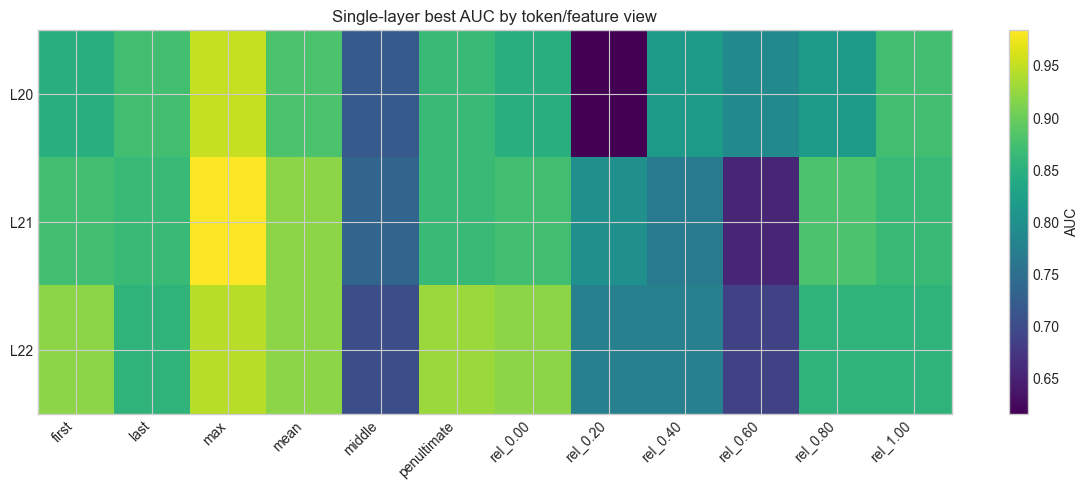

,global_layer_idx,local_layer_pos,layer_label,layer_name,feature_view,model,auc_mean,auc_std,acc_mean,acc_std
5,20,0,L20,encoder.T5Block.T5LayerSelfAttention.SelfAtten...,max,logreg_raw,0.952,0.071554,0.86,0.114018
17,21,1,L21,encoder.T5Block.T5LayerSelfAttention.SelfAtten...,max,linear_svm,0.984,0.035777,0.84,0.114018
29,22,2,L22,encoder.T5Block.T5LayerSelfAttention.SelfAtten...,max,linear_svm,0.944,0.045607,0.88,0.044721


In [9]:
heatmap_df = single_df.pivot_table(index="layer_label", columns="feature_view", values="auc_mean", aggfunc="max")
fig, ax = plt.subplots(figsize=(12, 5))
im = ax.imshow(heatmap_df.values, aspect="auto", cmap="viridis")
ax.set_xticks(np.arange(len(heatmap_df.columns)))
ax.set_xticklabels(heatmap_df.columns, rotation=45, ha="right")
ax.set_yticks(np.arange(len(heatmap_df.index)))
ax.set_yticklabels(heatmap_df.index)
ax.set_title("Single-layer best AUC by token/feature view")
fig.colorbar(im, ax=ax, label="AUC")
plt.tight_layout()
plt.show()

best_per_layer_df = single_df.sort_values(["global_layer_idx", "auc_mean"], ascending=[True, False]).groupby("global_layer_idx").head(1)
best_per_layer_df

In [10]:
bundle_rows = []
for size in range(2, min(MAX_BUNDLE_SIZE, len(candidate_indices)) + 1):
    for start in range(0, len(candidate_indices) - size + 1):
        layer_positions = list(range(start, start + size))
        global_layers = [candidate_indices[pos] for pos in layer_positions]
        bundle_name = "+".join(layer_labels[idx] for idx in global_layers)
        for spec in bundle_specs:
            X = build_bundle_matrix(all_seqs, layer_positions, spec)
            results = evaluate_models(X, y, fast=FAST_BUNDLE_SWEEP)
            best = results.iloc[0].to_dict()
            bundle_rows.append({
                "bundle_name": bundle_name,
                "bundle_size": size,
                "start_global_layer": global_layers[0],
                "end_global_layer": global_layers[-1],
                "feature_view": spec["name"],
                **best,
            })

bundle_df = pd.DataFrame(bundle_rows).sort_values("auc_mean", ascending=False)
bundle_df.head(20)

,bundle_name,bundle_size,start_global_layer,end_global_layer,feature_view,model,auc_mean,auc_std,acc_mean,acc_std
2,L21+L22,2,21,22,first,logreg_raw,0.928,0.043818,0.78,0.130384
3,L21+L22,2,21,22,mean,logreg_raw,0.904,0.060663,0.82,0.083666
5,L20+L21+L22,3,20,22,mean,logreg_raw,0.896,0.060663,0.80,0.100000
4,L20+L21+L22,3,20,22,first,logreg_raw,0.888,0.076942,0.78,0.130384
1,L20+L21,2,20,21,mean,logreg_raw,0.880,0.056569,0.80,0.070711
0,L20+L21,2,20,21,first,logreg_raw,0.872,0.065727,0.76,0.114018


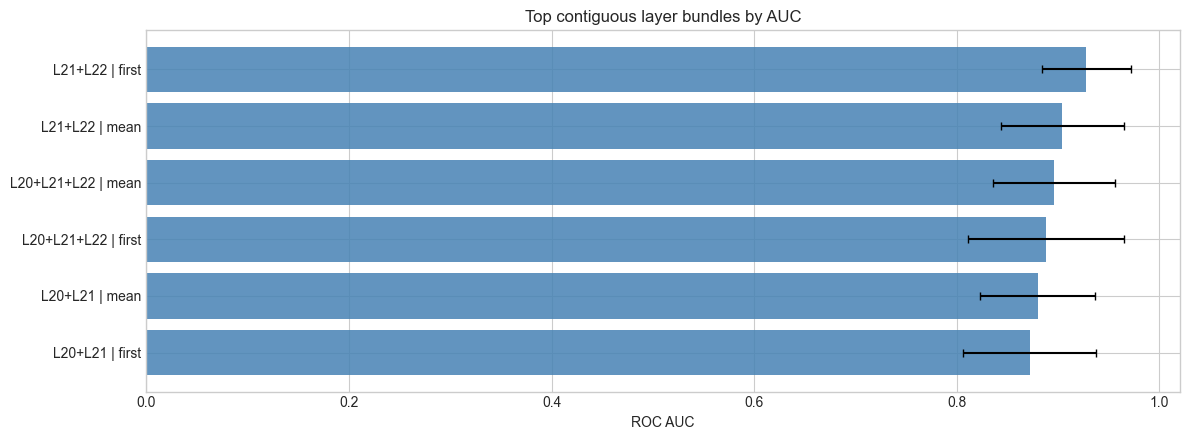

In [11]:
fig, ax = plt.subplots(figsize=(12, 4.5))
top_bundles = bundle_df.head(12).iloc[::-1]
ax.barh(top_bundles["bundle_name"] + " | " + top_bundles["feature_view"], top_bundles["auc_mean"], color="steelblue", alpha=0.85)
ax.errorbar(top_bundles["auc_mean"], top_bundles["bundle_name"] + " | " + top_bundles["feature_view"], xerr=top_bundles["auc_std"], fmt="none", ecolor="black", capsize=3)
ax.set_title("Top contiguous layer bundles by AUC")
ax.set_xlabel("ROC AUC")
plt.tight_layout()
plt.show()

In [12]:
def pca_subspace(X, n_components):
    k = max(1, min(n_components, X.shape[0] - 1, X.shape[1]))
    pca = PCA(n_components=k, random_state=RANDOM_STATE).fit(X)
    return pca.mean_, pca.components_

def reconstruction_error(X, mean_vec, components):
    centered = X - mean_vec
    coeff = centered @ components.T
    recon = mean_vec + coeff @ components
    return np.linalg.norm(X - recon, axis=1)

def principal_angles_deg(components_a, components_b):
    svals = np.linalg.svd(components_a @ components_b.T, compute_uv=False)
    svals = np.clip(svals, -1.0, 1.0)
    return np.degrees(np.arccos(svals))

def cluster_view(X, n_clusters=2):
    scaled = StandardScaler().fit_transform(X).astype(np.float64)
    pca2 = PCA(n_components=2, random_state=RANDOM_STATE)
    proj = pca2.fit_transform(scaled)
    km = KMeans(n_clusters=n_clusters, random_state=RANDOM_STATE, n_init=20)
    km_labels = km.fit_predict(scaled)
    gmm_labels = None
    for covariance_type in ["full", "diag"]:
        try:
            gmm = GaussianMixture(n_components=n_clusters, covariance_type=covariance_type, reg_covar=1e-5, n_init=5, random_state=RANDOM_STATE)
            gmm_labels = gmm.fit_predict(scaled)
            break
        except ValueError:
            continue
    if gmm_labels is None:
        gmm_labels = np.zeros(len(scaled), dtype=int)
    sil_km = silhouette_score(scaled, km_labels) if len(np.unique(km_labels)) > 1 else np.nan
    sil_gmm = silhouette_score(scaled, gmm_labels) if len(np.unique(gmm_labels)) > 1 else np.nan
    ari = adjusted_rand_score(km_labels, gmm_labels) if len(np.unique(gmm_labels)) > 1 else np.nan
    return proj, km_labels, gmm_labels, sil_km, sil_gmm, ari

def deep_dive_feature_matrix(kind, row):
    if kind == "single":
        return build_single_layer_matrix(all_seqs, int(row["local_layer_pos"]), {"name": row["feature_view"], "kind": "pool", "mode": row["feature_view"]})
    raise ValueError("Use the explicit builder below for non-pool single-layer rows.")

In [13]:
def spec_from_name(name):
    for spec in single_layer_specs + bundle_specs:
        if spec["name"] == name:
            return spec
    raise KeyError(name)

def build_matrix_from_result_row(row, is_bundle=False):
    spec = spec_from_name(row["feature_view"])
    if not is_bundle:
        return build_single_layer_matrix(all_seqs, int(row["local_layer_pos"]), spec)
    bundle_labels = row["bundle_name"].split("+")
    global_layers = [layer_labels.index(label) for label in bundle_labels]
    layer_positions = [candidate_indices.index(idx) for idx in global_layers]
    return build_bundle_matrix(all_seqs, layer_positions, spec)

top_single = single_df.head(TOP_RESULTS_TO_DEEP_DIVE).copy()
top_single["result_type"] = "single"
top_bundle = bundle_df.head(TOP_RESULTS_TO_DEEP_DIVE).copy()
top_bundle["result_type"] = "bundle"

deep_dive_rows = []
for _, row in top_single.iterrows():
    X = build_matrix_from_result_row(row, is_bundle=False)
    probe = Pipeline([
        ("scale", StandardScaler()),
        ("clf", LogisticRegression(max_iter=2000, solver="liblinear", random_state=RANDOM_STATE)),
    ])
    margins = cross_val_predict(probe, X, y, cv=cv, method="decision_function")
    probe.fit(X, y)
    coef = probe.named_steps["clf"].coef_[0]
    top_dims = np.argsort(np.abs(coef))[::-1][:TOP_DIMS_TO_SHOW]
    X0 = X[y == 0]
    X1 = X[y == 1]
    mean0, comp0 = pca_subspace(X0, PCA_COMPONENTS)
    mean1, comp1 = pca_subspace(X1, PCA_COMPONENTS)
    angles = principal_angles_deg(comp0, comp1)
    err_00 = reconstruction_error(X0, mean0, comp0)
    err_01 = reconstruction_error(X0, mean1, comp1)
    err_11 = reconstruction_error(X1, mean1, comp1)
    err_10 = reconstruction_error(X1, mean0, comp0)
    proj0, km0, gmm0, sil_km0, sil_gmm0, ari0 = cluster_view(X0)
    proj1, km1, gmm1, sil_km1, sil_gmm1, ari1 = cluster_view(X1)
    pca2 = PCA(n_components=2, random_state=RANDOM_STATE)
    proj_all = pca2.fit_transform(StandardScaler().fit_transform(X))
    deep_dive_rows.append({
        "descriptor": f"single {row['layer_label']} | {row['feature_view']}",
        "auc_mean": row["auc_mean"],
        "auc_std": row["auc_std"],
        "margin_scores": margins,
        "top_dims": top_dims,
        "top_dim_weights": coef[top_dims],
        "mean_principal_angle_deg": float(angles.mean()),
        "class0_cross_subspace_ratio": float(err_01.mean() / max(err_00.mean(), 1e-12)),
        "class1_cross_subspace_ratio": float(err_10.mean() / max(err_11.mean(), 1e-12)),
        "proj_all": proj_all,
        "proj0": proj0,
        "proj1": proj1,
        "km0": km0,
        "km1": km1,
        "gmm0": gmm0,
        "gmm1": gmm1,
        "sil_km0": sil_km0,
        "sil_km1": sil_km1,
        "sil_gmm0": sil_gmm0,
        "sil_gmm1": sil_gmm1,
        "ari0": ari0,
        "ari1": ari1,
    })

for _, row in top_bundle.iterrows():
    X = build_matrix_from_result_row(row, is_bundle=True)
    probe = Pipeline([
        ("scale", StandardScaler()),
        ("clf", LogisticRegression(max_iter=2000, solver="liblinear", random_state=RANDOM_STATE)),
    ])
    margins = cross_val_predict(probe, X, y, cv=cv, method="decision_function")
    probe.fit(X, y)
    coef = probe.named_steps["clf"].coef_[0]
    top_dims = np.argsort(np.abs(coef))[::-1][:TOP_DIMS_TO_SHOW]
    X0 = X[y == 0]
    X1 = X[y == 1]
    mean0, comp0 = pca_subspace(X0, PCA_COMPONENTS)
    mean1, comp1 = pca_subspace(X1, PCA_COMPONENTS)
    angles = principal_angles_deg(comp0, comp1)
    err_00 = reconstruction_error(X0, mean0, comp0)
    err_01 = reconstruction_error(X0, mean1, comp1)
    err_11 = reconstruction_error(X1, mean1, comp1)
    err_10 = reconstruction_error(X1, mean0, comp0)
    proj0, km0, gmm0, sil_km0, sil_gmm0, ari0 = cluster_view(X0)
    proj1, km1, gmm1, sil_km1, sil_gmm1, ari1 = cluster_view(X1)
    pca2 = PCA(n_components=2, random_state=RANDOM_STATE)
    proj_all = pca2.fit_transform(StandardScaler().fit_transform(X))
    deep_dive_rows.append({
        "descriptor": f"bundle {row['bundle_name']} | {row['feature_view']}",
        "auc_mean": row["auc_mean"],
        "auc_std": row["auc_std"],
        "margin_scores": margins,
        "top_dims": top_dims,
        "top_dim_weights": coef[top_dims],
        "mean_principal_angle_deg": float(angles.mean()),
        "class0_cross_subspace_ratio": float(err_01.mean() / max(err_00.mean(), 1e-12)),
        "class1_cross_subspace_ratio": float(err_10.mean() / max(err_11.mean(), 1e-12)),
        "proj_all": proj_all,
        "proj0": proj0,
        "proj1": proj1,
        "km0": km0,
        "km1": km1,
        "gmm0": gmm0,
        "gmm1": gmm1,
        "sil_km0": sil_km0,
        "sil_km1": sil_km1,
        "sil_gmm0": sil_gmm0,
        "sil_gmm1": sil_gmm1,
        "ari0": ari0,
        "ari1": ari1,
    })

deep_dive_summary_df = pd.DataFrame([{k: v for k, v in row.items() if not isinstance(v, np.ndarray)} for row in deep_dive_rows])
deep_dive_summary_df

,descriptor,auc_mean,auc_std,mean_principal_angle_deg,class0_cross_subspace_ratio,class1_cross_subspace_ratio,sil_km0,sil_km1,sil_gmm0,sil_gmm1,ari0,ari1
0,single L21 | max,0.984,0.035777,73.626700,5.144975,3.138137,0.238534,0.111107,0.238534,0.111107,1.000000,1.000000
1,single L20 | max,0.952,0.071554,73.885511,5.154659,2.771762,0.242145,0.124243,0.242145,0.087156,1.000000,0.335813
2,single L22 | max,0.944,0.045607,73.307716,6.132944,3.112959,0.230625,0.202070,0.217192,0.171290,0.833611,0.686307
3,bundle L21+L22 | first,0.928,0.043818,59.878249,5.313421,3.362687,0.287909,0.200230,0.254132,0.200230,0.555735,1.000000
4,bundle L21+L22 | mean,0.904,0.060663,62.614344,7.955538,4.142725,0.386158,0.210112,0.386158,0.196174,1.000000,0.160000
5,bundle L20+L21+L22 | mean,0.896,0.060663,63.724847,8.080188,4.143585,0.393961,0.219356,0.393961,0.193677,1.000000,0.160000


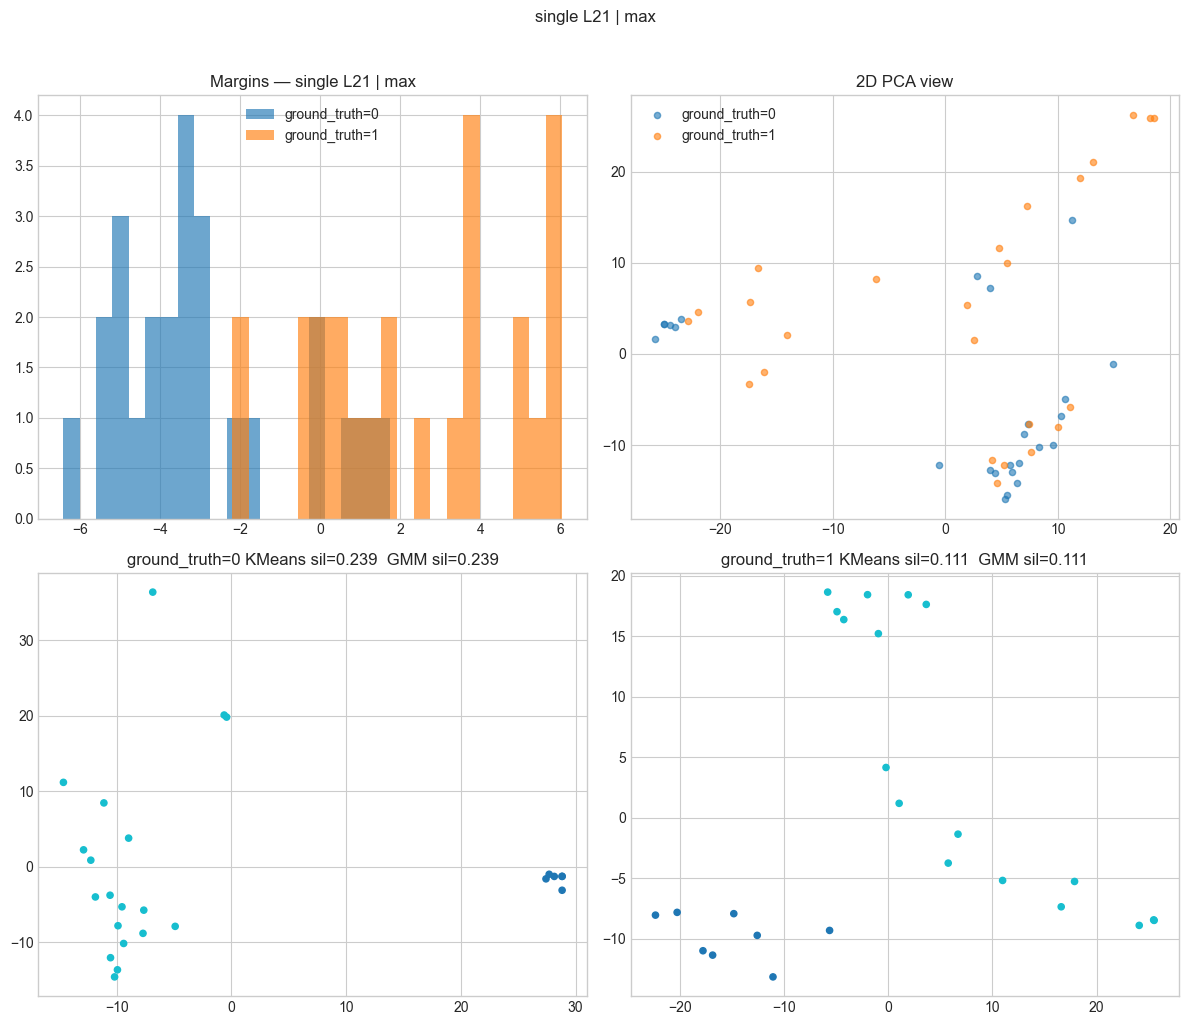

Top probe dimensions:


,dim,weight
0,839,0.107971
1,637,0.102507
2,77,-0.098341
3,161,0.095212
4,312,-0.094590
5,191,0.094436
6,490,0.094007
7,901,-0.093726
8,262,-0.092127
9,23,-0.092029


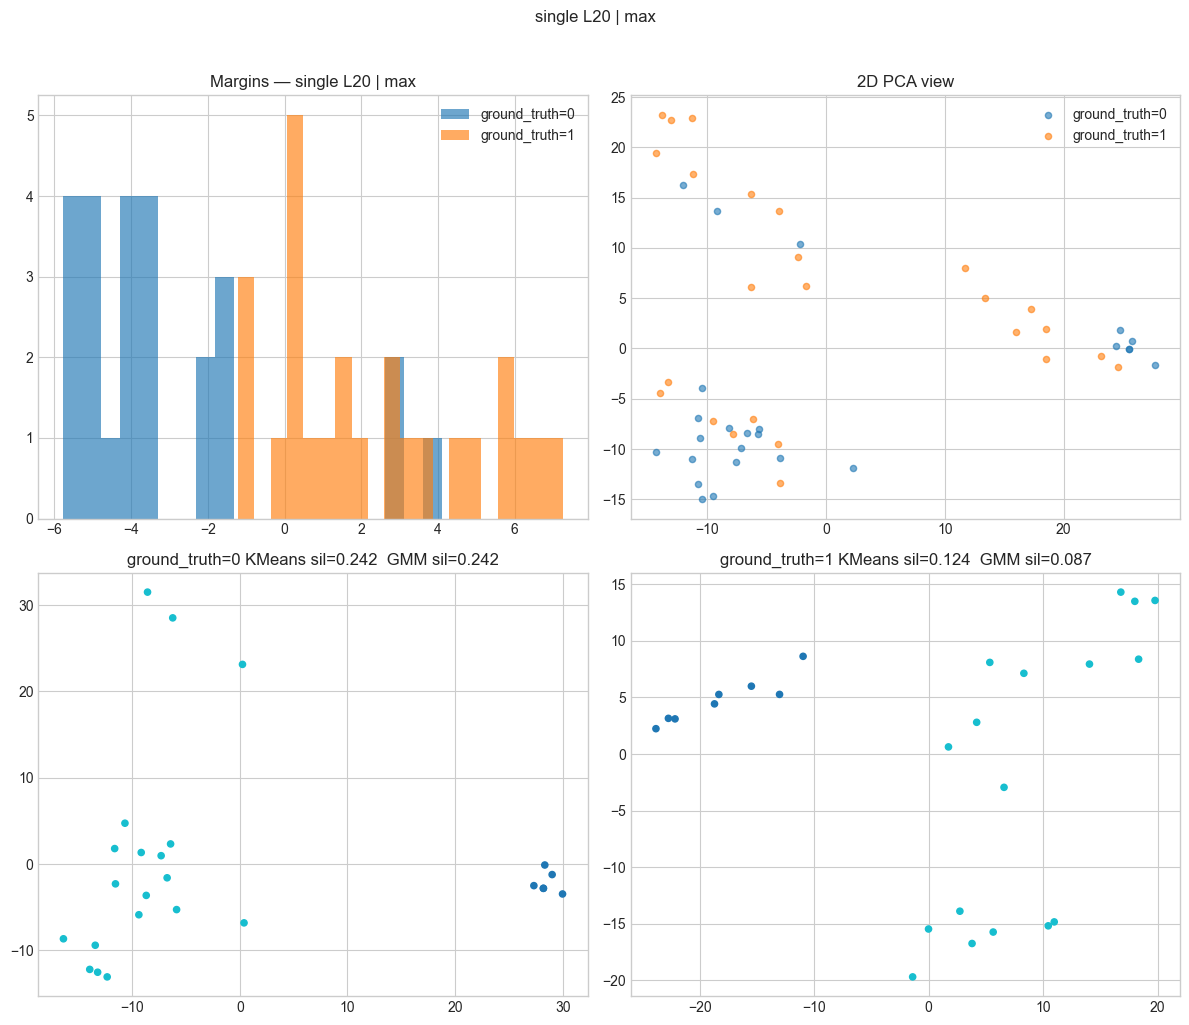

Top probe dimensions:


,dim,weight
0,426,0.105810
1,912,-0.100805
2,558,0.095058
3,764,0.092656
4,741,-0.091516
5,454,-0.091252
6,123,0.089684
7,19,0.088696
8,331,0.084588
9,675,-0.083863


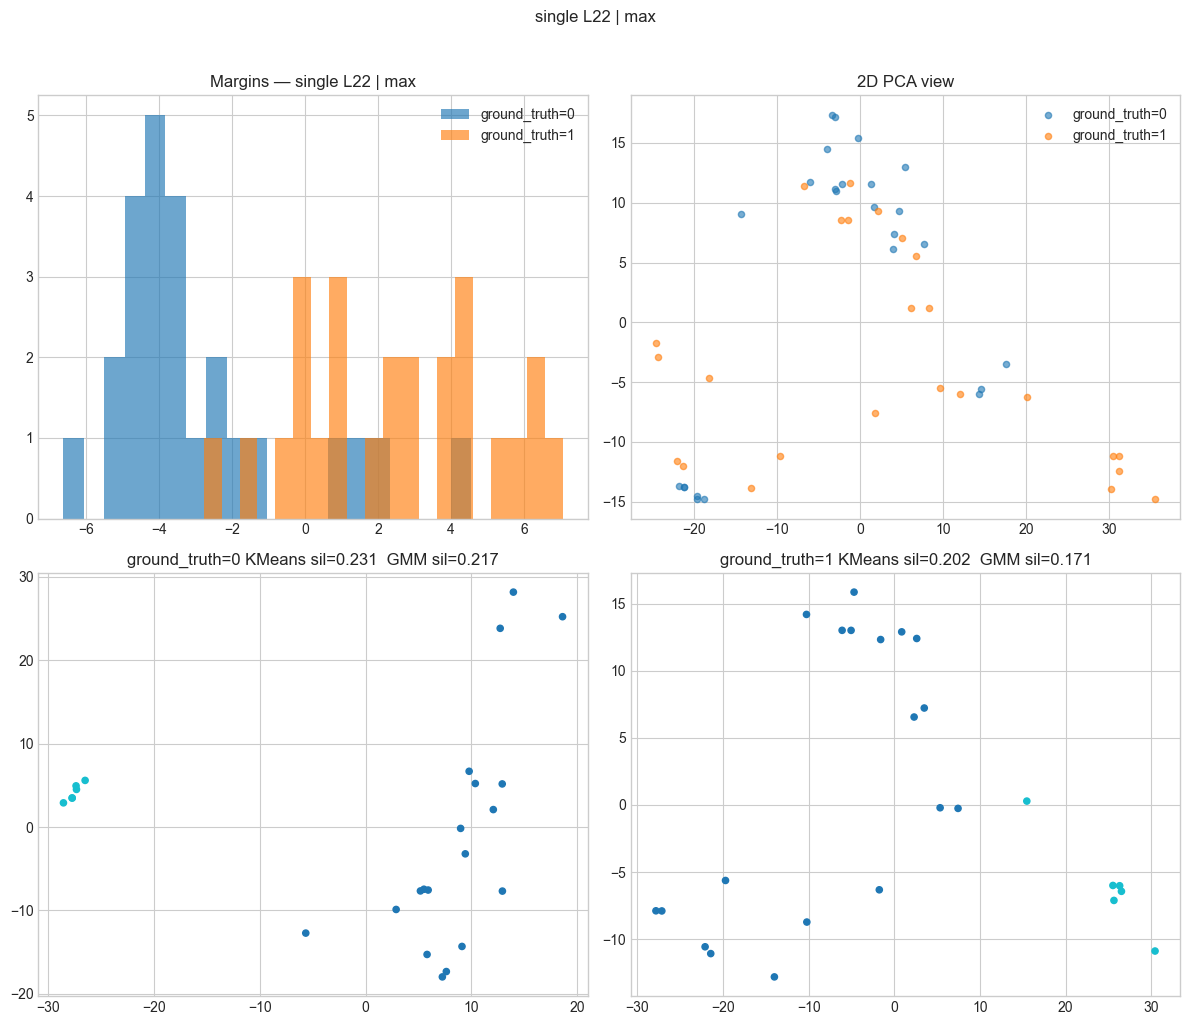

Top probe dimensions:


,dim,weight
0,292,-0.132752
1,935,-0.120828
2,843,0.120813
3,684,-0.117204
4,202,-0.104020
5,58,0.101336
6,720,-0.097520
7,865,0.095431
8,555,-0.095125
9,459,0.092913


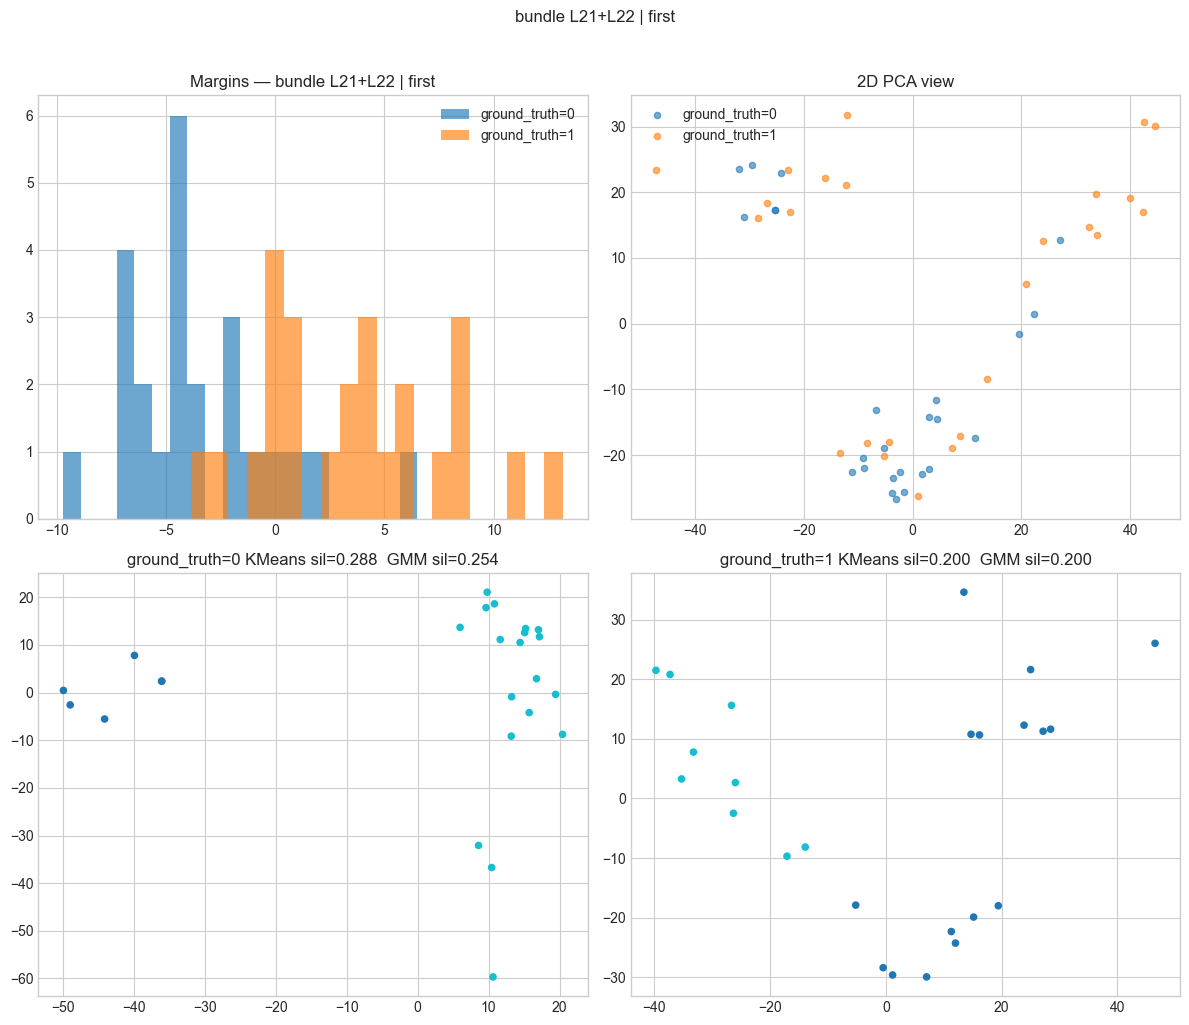

Top probe dimensions:


,dim,weight
0,720,-0.108830
1,962,0.093643
2,881,-0.089563
3,173,0.087678
4,249,-0.083455
5,40,-0.082981
6,762,0.082319
7,629,0.082063
8,732,0.081645
9,890,-0.081531


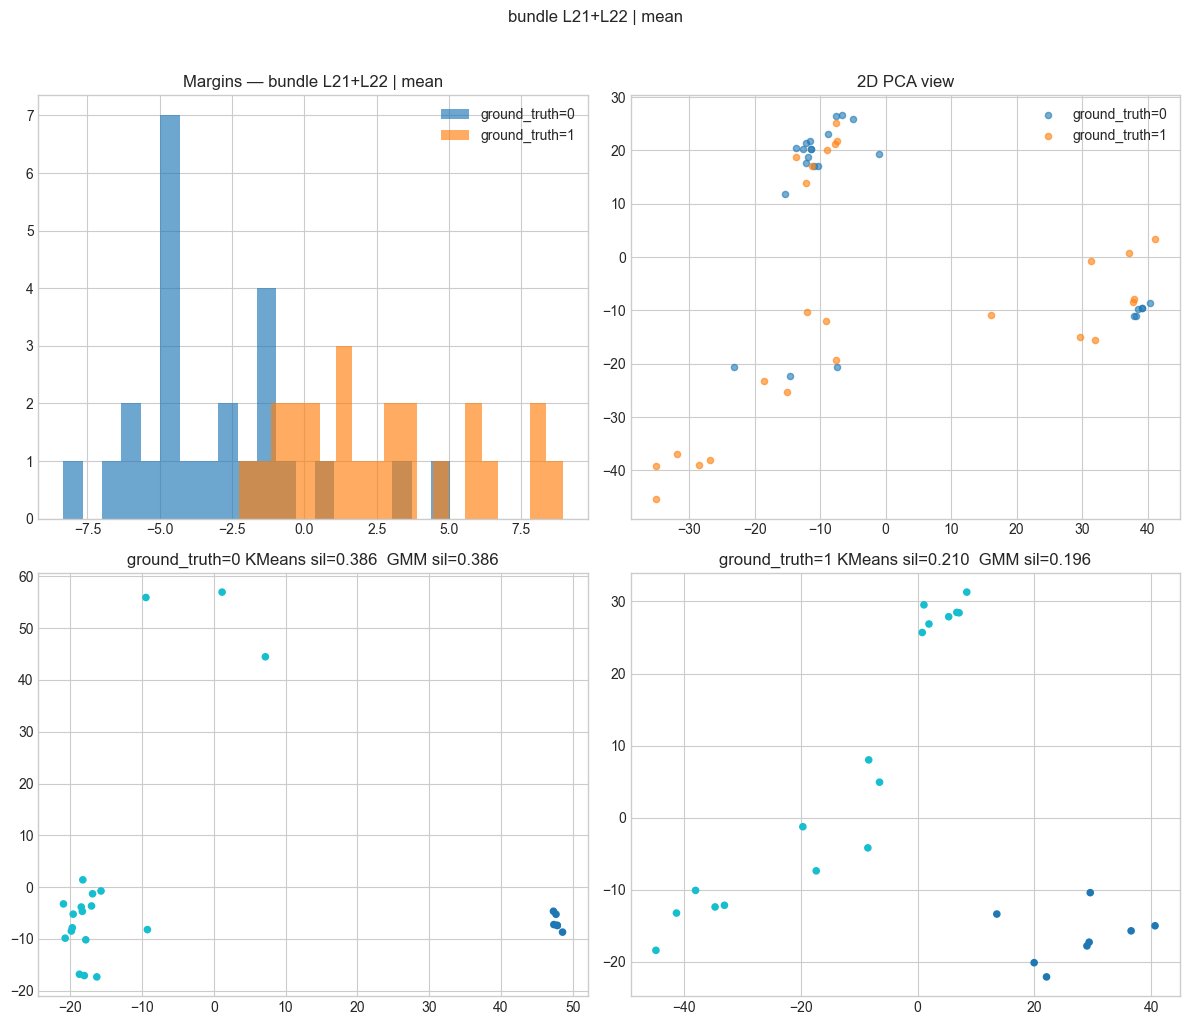

Top probe dimensions:


,dim,weight
0,1239,-0.134734
1,92,-0.105673
2,273,-0.100478
3,438,-0.095370
4,1809,-0.091248
5,1842,-0.089287
6,325,0.085516
7,466,0.079705
8,1966,-0.079284
9,1315,-0.078496


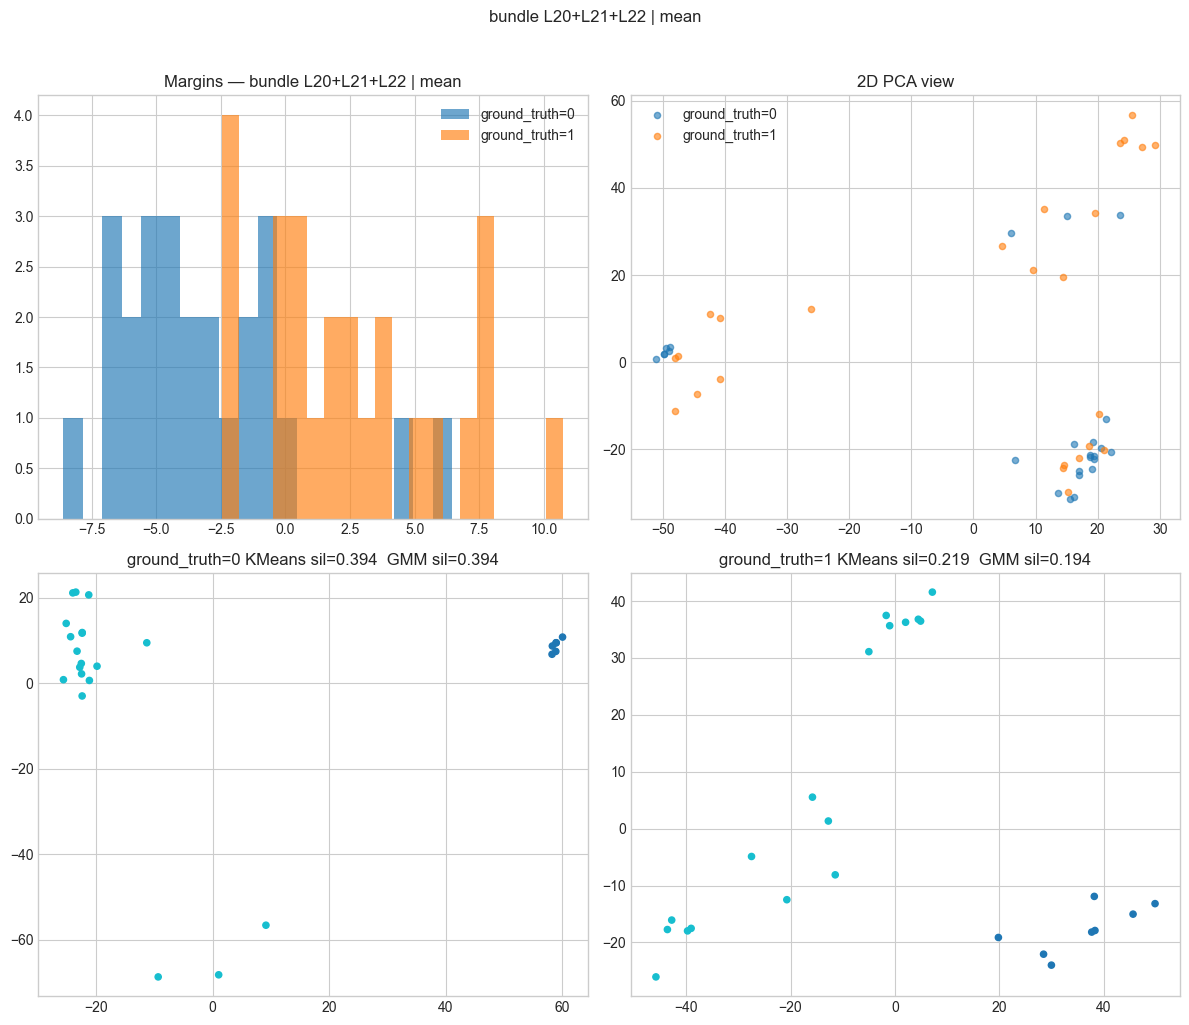

Top probe dimensions:


,dim,weight
0,2263,-0.099786
1,1297,-0.075005
2,1116,-0.074654
3,1462,-0.072123
4,2866,-0.069240
5,2833,-0.068492
6,2990,-0.065289
7,2339,-0.063403
8,234,-0.060533
9,1349,0.059874


In [14]:
for row in deep_dive_rows:
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    margins = row["margin_scores"]
    axes[0, 0].hist(margins[y == 0], bins=20, alpha=0.65, label=LABEL_0)
    axes[0, 0].hist(margins[y == 1], bins=20, alpha=0.65, label=LABEL_1)
    axes[0, 0].set_title(f"Margins — {row['descriptor']}")
    axes[0, 0].legend()

    proj_all = row["proj_all"]
    axes[0, 1].scatter(proj_all[y == 0, 0], proj_all[y == 0, 1], alpha=0.6, s=20, label=LABEL_0)
    axes[0, 1].scatter(proj_all[y == 1, 0], proj_all[y == 1, 1], alpha=0.6, s=20, label=LABEL_1)
    axes[0, 1].set_title("2D PCA view")
    axes[0, 1].legend()

    axes[1, 0].scatter(row["proj0"][:, 0], row["proj0"][:, 1], c=row["km0"], cmap="tab10", s=20)
    axes[1, 0].set_title(f"{LABEL_0} KMeans sil={row['sil_km0']:.3f}  GMM sil={row['sil_gmm0']:.3f}")

    axes[1, 1].scatter(row["proj1"][:, 0], row["proj1"][:, 1], c=row["km1"], cmap="tab10", s=20)
    axes[1, 1].set_title(f"{LABEL_1} KMeans sil={row['sil_km1']:.3f}  GMM sil={row['sil_gmm1']:.3f}")

    plt.suptitle(row["descriptor"], y=1.02)
    plt.tight_layout()
    plt.show()
    print("Top probe dimensions:")
    display(pd.DataFrame({"dim": row["top_dims"], "weight": row["top_dim_weights"]}))


In [15]:
best_single = single_df.iloc[0]
best_bundle = bundle_df.iloc[0] if len(bundle_df) else None
summary = {
    "center_layer_index": CENTER_LAYER_INDEX,
    "layer_filter": LAYER_NAME_FILTER,
    "candidate_global_layers": candidate_indices,
    "best_single_layer": f"{best_single['layer_label']} | {best_single['feature_view']}",
    "best_single_model": best_single['model'],
    "best_single_auc": float(best_single['auc_mean']),
    "best_bundle": None if best_bundle is None else f"{best_bundle['bundle_name']} | {best_bundle['feature_view']}",
    "best_bundle_model": None if best_bundle is None else best_bundle['model'],
    "best_bundle_auc": None if best_bundle is None else float(best_bundle['auc_mean']),
}
summary

{'center_layer_index': 21,
 'layer_filter': 'SelfAttention.o',
 'candidate_global_layers': [20, 21, 22],
 'best_single_layer': 'L21 | max',
 'best_single_model': 'linear_svm',
 'best_single_auc': 0.984,
 'best_bundle': 'L21+L22 | first',
 'best_bundle_model': 'logreg_raw',
 'best_bundle_auc': 0.9279999999999999}

In [18]:
# Multi-dataset train / validation generalization setup
# ground_truth_type: "int", "bool", or "mixed"
TRAIN_DATASETS = [
    {
        "name": "HaluBench",
        "application_name": APPLICATION_NAME,
        "sub_application_name": SUB_APPLICATION_NAME,
        "ground_truth_type": "int",
        "base_query": BASE_QUERY,
        "max_scans_per_class": MAX_SCANS_PER_CLASS,
        "validation_fraction": 0.2,
    },
]

EXTERNAL_VALIDATION_DATASETS = [
    {
        "name": "SquadV2",
        "application_name": "SquadV2",
        "sub_application_name": "right_wrong_pairs",
        "ground_truth_type": "bool",
        "base_query": {},
        "max_scans_per_class": 50,
    },
    # {
    #     "name": "Redis",
    #     "application_name": "redis",
    #     "sub_application_name": "quora_duplicates_t5_large",
    #     "ground_truth_type": "bool",
    #     "base_query": {},
    #     "max_scans_per_class": 50,
    # },
]

In [19]:
def fit_named_model(model_name, X_train, y_train):
    model = model_catalog(X_train.shape[1], len(y_train), PCA_COMPONENTS, fast=False)[model_name]
    model.fit(X_train, y_train)
    return model

def score_model(model, X_eval, y_eval):
    if len(X_eval) == 0:
        return {"auc": np.nan, "accuracy": np.nan, "n": 0}
    if hasattr(model, "decision_function"):
        score = model.decision_function(X_eval)
    elif hasattr(model, "predict_proba"):
        score = model.predict_proba(X_eval)[:, 1]
    else:
        score = model.predict(X_eval)
    pred = model.predict(X_eval)
    auc = np.nan
    if len(np.unique(y_eval)) >= 2:
        auc = float(roc_auc_score(y_eval, score))
    return {
        "auc": auc,
        "accuracy": float((pred == y_eval).mean()),
        "n": int(len(y_eval)),
    }

def resolve_bundle_positions(bundle_name):
    bundle_labels = bundle_name.split("+")
    global_layers = [layer_labels.index(label) for label in bundle_labels]
    return [candidate_indices.index(idx) for idx in global_layers]

def ground_truth_queries(ground_truth_type):
    gt_type = str(ground_truth_type).lower()
    if gt_type == "bool":
        return {"ground_truth": False}, {"ground_truth": True}
    if gt_type == "int":
        return {"ground_truth": {"$in": [0, "0"]}}, {"ground_truth": {"$in": [1, "1"]}}
    return {"ground_truth": {"$in": [0, "0", False]}}, {"ground_truth": {"$in": [1, "1", True]}}

def dataset_backend(dataset_cfg):
    backend_cfg = sdk_config.get_backend_config().copy()
    backend_cfg["scan_cache_directory"] = tempfile.gettempdir()
    return NSBackend({
        "application_name": dataset_cfg["application_name"],
        "sub_application_name": dataset_cfg["sub_application_name"],
        "backend_config": backend_cfg,
    })

def split_class_examples(seqs, val_fraction, rng):
    n = len(seqs)
    if n <= 1 or val_fraction <= 0:
        return list(seqs), []
    val_n = int(round(n * val_fraction))
    val_n = min(max(val_n, 1), n - 1)
    order = rng.permutation(n)
    val_idx = set(order[:val_n].tolist())
    train_part = [seqs[i] for i in range(n) if i not in val_idx]
    val_part = [seqs[i] for i in range(n) if i in val_idx]
    return train_part, val_part

def combine_sequence_groups(groups):
    seqs = []
    labels = []
    for group in groups:
        seqs.extend(group.get("seqs0", []))
        labels.extend([0] * len(group.get("seqs0", [])))
        seqs.extend(group.get("seqs1", []))
        labels.extend([1] * len(group.get("seqs1", [])))
    return seqs, np.array(labels, dtype=int)

def load_dataset_partition(dataset_cfg, candidate_layer_labels, layer_name_filter, seed_offset=0):
    be = dataset_backend(dataset_cfg)
    query_0_base, query_1_base = ground_truth_queries(dataset_cfg.get("ground_truth_type", "mixed"))
    query_0 = merged_query(dataset_cfg.get("base_query", {}), query_0_base)
    query_1 = merged_query(dataset_cfg.get("base_query", {}), query_1_base)
    max_scans = int(dataset_cfg.get("max_scans_per_class", 50))
    group_0, skipped_0 = load_scans_by_query(be, query_0, max_scans)
    group_1, skipped_1 = load_scans_by_query(be, query_1, max_scans)
    print(f"[{dataset_cfg['name']}] {LABEL_0}: loaded {len(group_0)} scans  (skipped {skipped_0})")
    print(f"[{dataset_cfg['name']}] {LABEL_1}: loaded {len(group_1)} scans  (skipped {skipped_1})")

    reference_layers = choose_reference_layers(group_0, group_1, layer_name_filter)
    label_to_layer_id = {layer_label: layer_id for layer_id, layer_label, _ in reference_layers}
    missing = [label for label in candidate_layer_labels if label not in label_to_layer_id]
    if missing:
        raise ValueError(f"Dataset {dataset_cfg['name']} is missing candidate layers: {missing}")
    candidate_layer_ids = [label_to_layer_id[label] for label in candidate_layer_labels]

    seqs0, _, dropped0 = build_layer_dataset(group_0, candidate_layer_ids)
    seqs1, _, dropped1 = build_layer_dataset(group_1, candidate_layer_ids)
    print(f"[{dataset_cfg['name']}] valid class-0: {len(seqs0)}  dropped {dropped0}")
    print(f"[{dataset_cfg['name']}] valid class-1: {len(seqs1)}  dropped {dropped1}")

    rng = np.random.default_rng(RANDOM_STATE + seed_offset)
    val_fraction = float(dataset_cfg.get("validation_fraction", 0.0))
    train0, val0 = split_class_examples(seqs0, val_fraction, rng)
    train1, val1 = split_class_examples(seqs1, val_fraction, rng)
    return {
        "name": dataset_cfg["name"],
        "train": {"seqs0": train0, "seqs1": train1},
        "internal_val": {"seqs0": val0, "seqs1": val1},
        "all": {"seqs0": seqs0, "seqs1": seqs1},
    }

candidate_layer_labels = [layer_labels[i] for i in candidate_indices]

best_single_row = single_df.iloc[0]
best_bundle_row = bundle_df.iloc[0] if len(bundle_df) else None

artifact_specs = [
    {
        "artifact": "best_single",
        "descriptor": f"{best_single_row['layer_label']} | {best_single_row['feature_view']} | {best_single_row['model']}",
        "model_name": best_single_row["model"],
        "kind": "single",
        "layer_positions": [int(best_single_row["local_layer_pos"])],
        "spec": spec_from_name(best_single_row["feature_view"]),
    },
]
if best_bundle_row is not None:
    artifact_specs.append(
        {
            "artifact": "best_bundle",
            "descriptor": f"{best_bundle_row['bundle_name']} | {best_bundle_row['feature_view']} | {best_bundle_row['model']}",
            "model_name": best_bundle_row["model"],
            "kind": "bundle",
            "layer_positions": resolve_bundle_positions(best_bundle_row["bundle_name"]),
            "spec": spec_from_name(best_bundle_row["feature_view"]),
        }
    )

train_dataset_parts = [
    load_dataset_partition(dataset_cfg, candidate_layer_labels, LAYER_NAME_FILTER, seed_offset=i)
    for i, dataset_cfg in enumerate(TRAIN_DATASETS)
]
external_dataset_parts = [
    load_dataset_partition(dataset_cfg, candidate_layer_labels, LAYER_NAME_FILTER, seed_offset=100 + i)
    for i, dataset_cfg in enumerate(EXTERNAL_VALIDATION_DATASETS)
]

train_seqs, train_y = combine_sequence_groups([part["train"] for part in train_dataset_parts])
internal_val_seqs, internal_val_y = combine_sequence_groups([part["internal_val"] for part in train_dataset_parts])

validation_sets = []
for part in train_dataset_parts:
    seqs, labels = combine_sequence_groups([part["internal_val"]])
    validation_sets.append({
        "validation_group": "internal_holdout",
        "validation_name": part["name"],
        "seqs": seqs,
        "y": labels,
    })
if len(internal_val_seqs):
    validation_sets.append({
        "validation_group": "internal_holdout",
        "validation_name": "all_train_dataset_holdouts",
        "seqs": internal_val_seqs,
        "y": internal_val_y,
    })
for part in external_dataset_parts:
    seqs, labels = combine_sequence_groups([part["all"]])
    validation_sets.append({
        "validation_group": "external_dataset",
        "validation_name": part["name"],
        "seqs": seqs,
        "y": labels,
    })
external_all_seqs, external_all_y = combine_sequence_groups([part["all"] for part in external_dataset_parts])
if len(external_all_seqs):
    validation_sets.append({
        "validation_group": "external_dataset",
        "validation_name": "all_external_datasets",
        "seqs": external_all_seqs,
        "y": external_all_y,
    })
combined_val_seqs, combined_val_y = combine_sequence_groups(
    [part["internal_val"] for part in train_dataset_parts] + [part["all"] for part in external_dataset_parts]
)
if len(combined_val_seqs):
    validation_sets.append({
        "validation_group": "all_validation",
        "validation_name": "internal_plus_external",
        "seqs": combined_val_seqs,
        "y": combined_val_y,
    })

def feature_matrix_for_artifact(seqs, artifact_spec):
    if artifact_spec["kind"] == "single":
        return build_single_layer_matrix(seqs, artifact_spec["layer_positions"][0], artifact_spec["spec"])
    return build_bundle_matrix(seqs, artifact_spec["layer_positions"], artifact_spec["spec"])

trained_artifacts = []
for artifact_spec in artifact_specs:
    X_train = feature_matrix_for_artifact(train_seqs, artifact_spec)
    fitted = fit_named_model(artifact_spec["model_name"], X_train, train_y)
    train_scores = score_model(fitted, X_train, train_y)
    trained_artifacts.append({
        **artifact_spec,
        "model": fitted,
        "train_scores": train_scores,
    })

print(f"Combined training scans: {len(train_seqs)}")
print(f"Validation sets available: {len(validation_sets)}")

Transfer ground_truth=0: loaded 50 scans  (skipped 0)
Transfer ground_truth=1: loaded 50 scans  (skipped 0)
Transfer valid class-0: 50  dropped 0
Transfer valid class-1: 50  dropped 0


In [20]:
generalization_rows = []
for artifact in trained_artifacts:
    generalization_rows.append({
        "artifact": artifact["artifact"],
        "descriptor": artifact["descriptor"],
        "validation_group": "train_combined",
        "validation_name": "all_train_datasets",
        "auc": artifact["train_scores"]["auc"],
        "accuracy": artifact["train_scores"]["accuracy"],
        "n": artifact["train_scores"]["n"],
    })
    for val_set in validation_sets:
        X_val = feature_matrix_for_artifact(val_set["seqs"], artifact)
        val_scores = score_model(artifact["model"], X_val, val_set["y"])
        generalization_rows.append({
            "artifact": artifact["artifact"],
            "descriptor": artifact["descriptor"],
            "validation_group": val_set["validation_group"],
            "validation_name": val_set["validation_name"],
            "auc": val_scores["auc"],
            "accuracy": val_scores["accuracy"],
            "n": val_scores["n"],
        })

generalization_results_df = pd.DataFrame(generalization_rows)
display(generalization_results_df.sort_values(["artifact", "validation_group", "validation_name"]).reset_index(drop=True))

for artifact_name, artifact_df in generalization_results_df.groupby("artifact"):
    descriptor = artifact_df.iloc[0]["descriptor"]
    print(f"{artifact_name}: {descriptor}")
    for _, row in artifact_df.iterrows():
        auc_text = "nan" if pd.isna(row["auc"]) else f"{row['auc']:.4f}"
        acc_text = "nan" if pd.isna(row["accuracy"]) else f"{row['accuracy']:.4f}"
        print(f"  {row['validation_group']} :: {row['validation_name']}  AUC={auc_text}  acc={acc_text}  n={int(row['n'])}")

,artifact,descriptor,source_auc,source_accuracy,transfer_auc,transfer_accuracy
0,best_single,L21 | max | linear_svm,1.0,1.0,0.6344,0.55
1,best_bundle,L21+L22 | first | logreg_raw,1.0,1.0,0.6848,0.62


best_single: L21 | max | linear_svm
  source   AUC=1.0000  acc=1.0000
  transfer AUC=0.6344  acc=0.5500
best_bundle: L21+L22 | first | logreg_raw
  source   AUC=1.0000  acc=1.0000
  transfer AUC=0.6848  acc=0.6200
